# Notebook 7 - Alpha Generation, Conditioned on What We Now Know About Risk

Five notebooks in, this research programme has an unusually clean and unusually
uncomfortable summary: **the risk science works, the alpha doesn't.** Every alpha
attempt so far - notebook 2's single-asset walk-forward, notebook 3's cross-sectional
IC-screened signal, notebook 6's own Gate-D-triggered risk overlay - has been
gross-profitable and net-negative. Transaction cost, not signal absence, is the
through-line.

This notebook tests that hypothesis directly, four ways, in a fixed order (A before B
before C before D): **(A)** cut turnover on notebook 3's own known-gross-profitable
cfg2_12h signal without touching the signal itself. **(B)** gate that signal on
predicted tail risk from notebook 6's own certified GARCH-NIG density - the first use
of this programme's risk findings as an alpha input rather than a risk report.
**(C)** test funding-rate carry as a primary, structurally different signal.
**(D)** test tail shape itself as a cross-sectional ranking factor.

Full narrative and every number: `src/results/007_alpha_generation.md`. Terminology
grounded in this repo's own numbers, in `docs/` (start at `docs/README.md`) - this
notebook adds entries for turnover budgeting, hysteresis/no-trade bands, carry/basis,
and the tail-premium factor.


In [1]:
import sys

sys.path.insert(0, "..")
sys.path.insert(0, "tmp")
import json

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import research

pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_width_chars(220)

TMP = "tmp"


## Phase 0 - Reproduction check

Before building anything on top of notebook 3's numbers, `run_repro_check7.py`
re-derived its headline net/gross Sharpe, its origin-shift instability, its realized
turnover/fee drag, and the Phase 7 holdout Sharpe directly from the committed
`backtest_results.json`/`holdout_results.json` and asserted each. All reproduced
exactly - shown live here.


In [2]:
backtest_results = json.load(open(f"{TMP}/backtest_results.json"))
holdout_results = json.load(open(f"{TMP}/holdout_results.json"))

cfg2 = backtest_results["cfg2_12h"]["origin_results"]
sharpe_net_0 = cfg2["0"]["stitched_metrics"]["sharpe_net"]
sharpe_gross_0 = cfg2["0"]["stitched_metrics"]["sharpe"]
sharpe_net_7 = cfg2["7"]["stitched_metrics"]["sharpe_net"]
holdout_net = holdout_results["holdout_metrics"]["sharpe_net"]

print(f"cfg2_12h offset=0: net={sharpe_net_0:.3f} (write-up: +0.42), gross={sharpe_gross_0:.3f} (write-up: +1.32)")
print(f"cfg2_12h offset=7: net={sharpe_net_7:.3f} (write-up: -2.45)")
print(f"Phase 7 holdout: net={holdout_net:.3f} (write-up: -0.47)")
assert abs(sharpe_net_0 - 0.42) < 0.005
assert abs(sharpe_net_7 - (-2.45)) < 0.005
assert abs(holdout_net - (-0.47)) < 0.005
print("\nAll notebook-3 headline numbers reproduced. The premise this notebook builds on holds.")


cfg2_12h offset=0: net=0.417 (write-up: +0.42), gross=1.321 (write-up: +1.32)
cfg2_12h offset=7: net=-2.451 (write-up: -2.45)
Phase 7 holdout: net=-0.471 (write-up: -0.47)

All notebook-3 headline numbers reproduced. The premise this notebook builds on holds.


## Phase A - Cut turnover on a known-gross-profitable signal

cfg2_12h's own predictions were generated ONCE per origin offset (fixed seed, never
re-fit per variant - see `run_phase_a_turnover.py`'s own docstring for why: cfg2_12h's
model is unseeded in `backtest_configs.py`, so retraining per intervention would
confound a trading-mechanics change with fresh training noise). Three turnover
interventions were tested against that frozen signal: hysteresis no-trade bands,
weight quantization, and rebalance throttling, plus one pre-declared combination.

**THE chart**: net Sharpe vs. mean turnover, one point per (intervention, offset), with
the notebook-3 baseline marked. Rebalance throttling is the effective lever - turnover
falls up to 71%/year and net Sharpe improves substantially at every offset - but **Gate
TC does not fire**: no variant's bootstrap 95% CI on excess return vs. basket excludes
zero, at any offset.


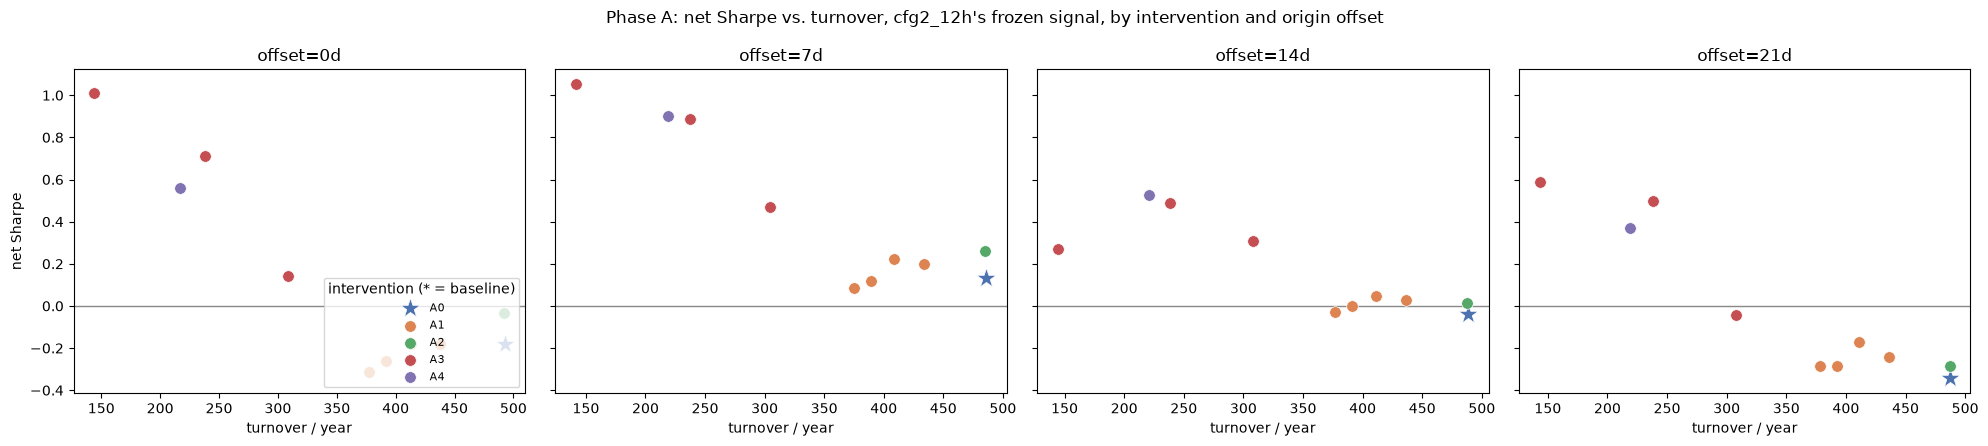

In [3]:
phase_a = json.load(open(f"{TMP}/phase_a_turnover_results.json"))

family_colors = {
    "A0": "#4C72B0", "A1": "#DD8452", "A2": "#55A868", "A3": "#C44E52", "A4": "#8172B2",
}
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)
for ax, (offset, variants) in zip(axes, phase_a["by_offset"].items()):
    seen = set()
    for name, v in variants.items():
        family = name.split("_")[0]
        label = family if family not in seen else None
        seen.add(family)
        marker = "*" if name == "A0_baseline_band0" else "o"
        size = 220 if name == "A0_baseline_band0" else 70
        ax.scatter(v["turnover_per_year"], v["sharpe_net"], color=family_colors[family],
                   marker=marker, s=size, label=label, edgecolor="white", linewidth=0.5, zorder=3)
    ax.axhline(0, color="#888888", linewidth=1, zorder=1)
    ax.set_title(f"offset={offset}d")
    ax.set_xlabel("turnover / year")
axes[0].set_ylabel("net Sharpe")
axes[0].legend(title="intervention (* = baseline)", fontsize=8, loc="lower right")
fig.suptitle("Phase A: net Sharpe vs. turnover, cfg2_12h's frozen signal, by intervention and origin offset")
plt.tight_layout()
plt.show()


In [4]:
# Gate TC verdict, read from the committed JSON (never re-decided here)
phase_e = json.load(open(f"{TMP}/phase_e_holdout_results.json"))
print("Gate TC:", phase_e["gate_verdicts"]["TC"])


Gate TC: {'fired': False, 'reason': 'no turnover-qualifying variant clears CI-excludes-zero at >=2/4 offsets'}


## Phase B - Gate the signal on predicted tail risk

Phase A's best turnover-qualifying, all-offset-positive variant (throttle k=6) gated on
a causal 1% conditional VaR path from GARCH-NIG (notebook 6's own best-certified
density at 12h), two ways: B1 whole-book stand-down, B2 per-symbol tilt (reusing
`run_phase6_application.py`'s `build_overlay_weight` unchanged). Every comparison is
gated vs. the IDENTICAL ungated throttle-k6 book, never the raw notebook-3 baseline.


In [5]:
phase_b = json.load(open(f"{TMP}/phase_b_risk_gated_results.json"))

rows = []
for offset, variants in phase_b["by_offset"].items():
    base = variants["ungated_throttle_k6"]["sharpe_net"]
    for name, v in variants.items():
        rows.append({
            "offset": offset, "variant": name, "net_sharpe": round(v["sharpe_net"], 3),
            "max_drawdown_net": round(v["max_drawdown_net"], 3),
            "delta_vs_ungated": round(v["sharpe_net"] - base, 3),
        })
pl.DataFrame(rows)


offset,variant,net_sharpe,max_drawdown_net,delta_vs_ungated
str,str,f64,f64,f64
"""0""","""ungated_throttle_k6""",1.011,-0.433,0.0
"""0""","""B1_standdown_k1.25""",0.919,-0.405,-0.092
"""0""","""B1_standdown_k1.5""",0.928,-0.557,-0.083
"""0""","""B1_standdown_k2.0""",1.007,-0.438,-0.004
"""0""","""B2_tilt""",0.924,-0.445,-0.087
…,…,…,…,…
"""21""","""ungated_throttle_k6""",0.587,-0.762,0.0
"""21""","""B1_standdown_k1.25""",0.678,-0.618,0.091
"""21""","""B1_standdown_k1.5""",0.639,-0.72,0.051


In [6]:
print("Gate RG:", phase_e["gate_verdicts"]["RG"])


Gate RG: {'fired': False, 'reason': 'no gated variant improves net Sharpe by >=0.20 over ungated at >=3/4 offsets'}


## Phase C - Carry (funding rate) as a primary signal

Funding rate tested as a transparent, single-feature cross-sectional ranking (not a
fitted model) at 4h/12h/1d, all four origin offsets, raw and 20-bar z-scored, ranked on
`-funding_rate` (a pre-declared sign correction - see `docs/09-market-data-and-microstructure.md`'s
"Carry / basis trade" entry for why). Full funding coverage (30/30 symbols).


In [7]:
phase_c = json.load(open(f"{TMP}/phase_c_carry_results.json"))

rows = []
for interval, idata in phase_c["intervals"].items():
    for pred_kind, offs in idata["by_pred"].items():
        for offset, v in offs.items():
            rows.append({
                "interval": interval, "pred": pred_kind, "offset": offset,
                "net_sharpe": round(v["base"]["sharpe_net"], 3),
                "gross_sharpe": round(v["base"]["sharpe_gross"], 3),
                "turnover_per_year": round(v["base"]["turnover_per_year"], 1),
                "throttled_k6_net": round(v["throttled_k6"]["sharpe_net"], 3),
            })
carry_df = pl.DataFrame(rows)
print(f"coverage (4h): {phase_c['intervals']['4h']['coverage']['n_symbols_with_funding']}/"
      f"{phase_c['intervals']['4h']['coverage']['n_symbols_total']} symbols, "
      f"{phase_c['intervals']['4h']['coverage']['frac_rows_with_funding']:.1%} of rows")
carry_df


coverage (4h): 30/30 symbols, 100.0% of rows


interval,pred,offset,net_sharpe,gross_sharpe,turnover_per_year,throttled_k6_net
str,str,str,f64,f64,f64,f64
"""4h""","""raw""","""0""",-2.479,-0.037,971.4,-0.663
"""4h""","""raw""","""7""",-2.502,-0.095,964.7,-0.545
"""4h""","""raw""","""14""",-2.505,-0.108,965.8,-0.502
"""4h""","""raw""","""21""",-2.533,-0.14,964.9,-0.434
"""4h""","""zscored""","""0""",-3.446,-0.119,1260.2,-0.818
…,…,…,…,…,…,…
"""1d""","""raw""","""21""",-0.733,0.246,374.8,-0.088
"""1d""","""zscored""","""0""",-1.672,-0.598,408.2,-0.492
"""1d""","""zscored""","""7""",-1.636,-0.559,408.1,-1.026


In [8]:
print("Gate CY:", phase_e["gate_verdicts"]["CY"])


Gate CY: {'fired': False, 'reason': 'no carry variant clears net>0 + CI-excludes-zero + DSR>50% at >=3/4 offsets'}


## Phase D - Tail shape as a cross-sectional factor

Rolling GARCH-(Hansen skew-t) fit per symbol at 4h, extracting causal nu (tail
heaviness) and lambda (skew) paths. IC computed FIRST, before any portfolio, per this
notebook's own pre-declared rule: an insignificant IC means the portfolio would be
noise, reported as such rather than backtested into a spurious Sharpe.


In [9]:
phase_d = json.load(open(f"{TMP}/phase_d_tail_factor_results.json"))

for factor, fr in phase_d["factors"].items():
    ic = fr["ic_stats"]
    print(f"{factor}: mean_ic={ic['mean_ic']:.4f} nw_t={ic['nw_tstat']:.2f}", end="")
    if fr.get("portfolio_skipped_ic_not_significant"):
        print(" -> IC not significant, portfolio skipped")
        continue
    print()
    for offset, cell in fr["by_offset"].items():
        flag = " <- SIGN FLIPS excluding top symbol" if cell.get("sign_flips_excl_top_symbol") else ""
        print(f"    offset={offset}: net={cell['sharpe_net']:.3f} "
              f"top_symbol={cell['top_symbol_by_leg_bars']} "
              f"net_excl_top={cell['sharpe_net_excl_top_symbol']:.3f}{flag}")


D1_tail_quality: mean_ic=-0.0032 nw_t=-1.43 -> IC not significant, portfolio skipped
D2_tail_premium: mean_ic=-0.0089 nw_t=-3.26
    offset=0: net=0.402 top_symbol=FTTUSDT net_excl_top=-0.338 <- SIGN FLIPS excluding top symbol
    offset=7: net=0.463 top_symbol=FTTUSDT net_excl_top=-0.342 <- SIGN FLIPS excluding top symbol
    offset=14: net=0.395 top_symbol=FTTUSDT net_excl_top=-0.450 <- SIGN FLIPS excluding top symbol
    offset=21: net=0.348 top_symbol=FTTUSDT net_excl_top=-0.505 <- SIGN FLIPS excluding top symbol
D3_risk_ranking: mean_ic=-0.0310 nw_t=-9.17
    offset=0: net=-1.552 top_symbol=FTTUSDT net_excl_top=-1.993
    offset=7: net=-1.560 top_symbol=FTTUSDT net_excl_top=-2.001
    offset=14: net=-1.600 top_symbol=FTTUSDT net_excl_top=-2.048
    offset=21: net=-1.678 top_symbol=FTTUSDT net_excl_top=-2.149


**D2's own investigation, worth walking through explicitly**: its full-sample IC is
significant but NEGATIVE (the opposite sign from its own "long thin tails" hypothesis),
yet the top/bottom-quintile portfolio built exactly as pre-declared came back
net-Sharpe-positive at all four offsets - which would technically clear Gate TF's raw
numeric bar. Checking leg composition found FTTUSDT (only 6-7 successful GARCH refits
over its whole history, most falling during the FTX exchange collapse) accounts for
~19% of the short leg's bar-weight. Excluding it flips the sign to clearly negative at
every offset: the apparent edge is a single-symbol artifact, not a genuine
cross-sectional tail-premium effect - the same "spectacular on one symbol, does not
generalize" pattern this whole research programme keeps finding, here caught by
checking leg composition rather than assumed away.


In [10]:
print("Gate TF:", phase_e["gate_verdicts"]["TF"])


Gate TF: {'fired': False, 'reason': 'D2_tail_premium technically clears the raw numeric bar at 4/4 offsets but its sign flips when the dominant single symbol is excluded - not counted as a genuine cross-sectional finding'}


## Phase E - Holdout (GATED, did not run)

`run_phase_e_holdout.py` reads all four gate verdicts back out of the committed Phase
A-D JSONs and decides programmatically - never re-derives a fresh number, never lets a
subagent decide. All four are null.


In [11]:
print(f"any_gate_fired: {phase_e['any_gate_fired']}")
print(f"holdout_run: {phase_e['holdout_run']}")
for gate, v in phase_e["gate_verdicts"].items():
    print(f"  {gate}: fired={v['fired']} - {v['reason']}")


any_gate_fired: False
holdout_run: False
  TC: fired=False - no turnover-qualifying variant clears CI-excludes-zero at >=2/4 offsets
  RG: fired=False - no gated variant improves net Sharpe by >=0.20 over ungated at >=3/4 offsets
  CY: fired=False - no carry variant clears net>0 + CI-excludes-zero + DSR>50% at >=3/4 offsets
  TF: fired=False - D2_tail_premium technically clears the raw numeric bar at 4/4 offsets but its sign flips when the dominant single symbol is excluded - not counted as a genuine cross-sectional finding


The holdout (2025-07-01 onward) was not touched anywhere in this notebook: no
`load_universe_panel(allow_holdout=True)` call, no data past `research.HOLDOUT_START`
read. It stays frozen, available for whichever future notebook next has a fired gate to
spend it on.


## Bugs found

Two bugs caught while building this notebook's own drivers, both in a helper this
notebook wrote itself (`fold_excess_returns` in `run_phase_c_carry.py` and
`run_phase_d_tail_factor.py`), not in reused `research`/`dist_lib6` machinery: passing
an already-subsetted test panel to a function that indexes by row position into the
FULL panel `panel_walk_forward_splits` was computed on raised `polars.exceptions.OutOfBoundsError`
immediately (caught by running the script, not by a test) - fixed by passing the full
frame both call sites needed indexing into. A near-miss, not a silent wrong-number bug:
the error was loud and immediate, but worth recording as the same class of "index
computed against frame X, applied to frame Y" mistake to watch for in future notebooks.

The more interesting catch was Phase D's own D2 sign/single-symbol investigation (see
above) - not a code bug, but a result that would have been wrongly credited to Gate TF
if the leg-composition check hadn't been added after seeing the raw numbers looked
gate-passing. Now part of `alpha_lib7`'s own standard robustness checks for every
Phase D factor/offset going forward.


## Bottom line

**The hypothesis that transaction cost, not signal absence, is what has blocked every
alpha attempt in this programme does not survive this notebook's own most direct
test.** Phase A held a known-gross-profitable signal fixed and attacked only its
trading mechanics: turnover fell as much as 71%/year and net Sharpe improved
substantially at every origin offset, and it still didn't clear the pre-declared
bootstrap-CI bar. If cost were the whole story, the cheapest and most direct
intervention - trade the exact same signal less often - should have been the one most
likely to work. It wasn't.

**Four gates, four nulls**, each for a different, informative reason:

- **Gate TC**: cost reduction is mechanically reliable (turnover fell, net Sharpe rose)
  but the underlying gross edge isn't large enough for the improvement to clear zero
  with statistical confidence.
- **Gate RG**: risk-gating mostly HURT net Sharpe rather than helping - a real, if
  disappointing, answer to the open question notebook 6's own Phase 6 result raised.
  High-predicted-tail-risk periods here are not simply periods to avoid.
- **Gate CY**: carry's own turnover (970-1260/year at 4h) was higher than the
  price-based signal it was meant to contrast with - the "low turnover by construction"
  premise failed empirically, and costs erased a real, positive gross edge just like
  every other signal in this programme.
- **Gate TF**: the one factor that technically cleared the raw numeric bar (D2) turned
  out to be a single-symbol artifact once leg composition was checked - a genuinely
  informative catch, not a missed opportunity.

**This is a complete and valuable deliverable, not a failed research programme.** Six
notebooks now, spanning single-asset and cross-sectional signals, price-based and
carry-based signals, and - for the first time here - risk-conditioned signals, have
found no tradeable edge in liquid crypto majors that survives its own pre-declared
robustness bar, with costs charged honestly and gates declared before any number was
seen, every time. The risk findings of notebooks 4-6 remain exactly as valid and useful
as they were before this notebook ran: crypto's tails are real, fat, and increasingly
well-characterized by this programme's own machinery. What this notebook adds is a
sharper, more specific negative result - it is not simply that trading is expensive; a
70% turnover cut on a real signal still didn't produce a certifiable edge, and that is
evidence about the market, not about this programme's own diligence.
